In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

# --- Trial Configuration ---
sites = ['001', '002', '003']
subjects_per_site = [18, 17, 15]  # total 50
visits = ['Screening', 'Cycle 1', 'Cycle 2', 'Cycle 3', 'End of Treatment']

# Normal ranges for edit checks later
NORMAL_RANGES = {
    'wbc': (4.0, 11.0),        # x10^9/L
    'hemoglobin': (12.0, 17.5), # g/dL
    'platelets': (150, 400),    # x10^9/L
    'tumor_size': (0, 150),     # mm (reasonable range)
    'ecog': (0, 4)              # performance status
}

records = []
subject_counter = 1

for site_idx, site in enumerate(sites):
    n_subjects = subjects_per_site[site_idx]
    
    for s in range(n_subjects):
        subject_id = f"{site}-{str(subject_counter).zfill(3)}"
        subject_counter += 1
        
        # Demographics (fixed per subject)
        age = random.randint(35, 75)
        sex = random.choice(['M', 'F'])
        race = random.choice(['White', 'Asian', 'Black', 'Hispanic'])
        
        # Enrollment date
        enrollment_date = datetime(2023, 1, 1) + timedelta(days=random.randint(0, 180))
        
        for visit_idx, visit in enumerate(visits):
            visit_date = enrollment_date + timedelta(days=visit_idx * 21)
            
            # CBC values
            wbc = round(random.uniform(3.5, 12.0), 1)
            hemoglobin = round(random.uniform(10.0, 18.0), 1)
            platelets = random.randint(100, 450)
            
            # Tumor assessment
            tumor_size = round(random.uniform(10, 120), 1)
            response = random.choice(['CR', 'PR', 'SD', 'PD'])
            
            # ECOG performance status
            ecog = random.randint(0, 3)
            
            # AE
            ae_term = random.choice(['Nausea', 'Fatigue', 'Neutropenia', 
                                     'Anaemia', 'Thrombocytopenia', 'None', 
                                     'None', 'None'])  # weighted toward None
            ae_grade = random.randint(1, 3) if ae_term != 'None' else None
            serious = 'Y' if ae_grade == 3 else ('N' if ae_grade else None)
            
            records.append({
                'subject_id': subject_id,
                'site': site,
                'visit': visit,
                'visit_date': visit_date.strftime('%Y-%m-%d'),
                'enrollment_date': enrollment_date.strftime('%Y-%m-%d'),
                'age': age,
                'sex': sex,
                'race': race,
                'ecog': ecog,
                'wbc': wbc,
                'hemoglobin': hemoglobin,
                'platelets': platelets,
                'tumor_size': tumor_size,
                'response': response,
                'ae_term': ae_term,
                'ae_grade': ae_grade,
                'serious_ae': serious
            })

df_clean = pd.DataFrame(records)
print(f"Clean dataset shape: {df_clean.shape}")
df_clean.head()

Clean dataset shape: (250, 17)


,subject_id,site,visit,visit_date,enrollment_date,age,sex,race,ecog,wbc,hemoglobin,platelets,tumor_size,response,ae_term,ae_grade,serious_ae
0,001-001,001,Screening,2023-03-12,2023-03-12,75,M,White,3,5.6,11.1,152,84.4,CR,Nausea,1.0,N
1,001-001,001,Cycle 1,2023-04-02,2023-03-12,75,M,White,3,4.3,11.9,408,12.9,PR,Anaemia,2.0,N
2,001-001,001,Cycle 2,2023-04-23,2023-03-12,75,M,White,3,8.5,16.5,103,93.5,PR,None,NaN,None
3,001-001,001,Cycle 3,2023-05-14,2023-03-12,75,M,White,0,5.9,11.7,272,21.2,PD,None,NaN,None
4,001-001,001,End of Treatment,2023-06-04,2023-03-12,75,M,White,3,10.7,14.8,122,90.3,CR,Fatigue,3.0,Y


In [2]:
import random
from datetime import datetime, timedelta

# Work on a copy so clean data is preserved
df = df_clean.copy()

# Helper to pick random row indices for a given site
def random_subjects(site, n):
    idx = df[(df['site'] == site)].index.tolist()
    return random.sample(idx, min(n, len(idx)))

# --- Error 1: Missing values (simulate incomplete CRF entries) ---
missing_idx = random.sample(list(df.index), 20)
for idx in missing_idx:
    field = random.choice(['wbc', 'hemoglobin', 'platelets', 'tumor_size', 'ecog'])
    df.at[idx, field] = np.nan

# --- Error 2: Out-of-range WBC (too high - possible data entry error) ---
high_wbc_idx = random_subjects('002', 5)
for idx in high_wbc_idx:
    df.at[idx, 'wbc'] = round(random.uniform(15.0, 25.0), 1)

# --- Error 3: Out-of-range Hemoglobin (critically low) ---
low_hb_idx = random_subjects('001', 4)
for idx in low_hb_idx:
    df.at[idx, 'hemoglobin'] = round(random.uniform(4.0, 7.0), 1)

# --- Error 4: Out-of-range Platelets (dangerously low) ---
low_plt_idx = random_subjects('003', 4)
for idx in low_plt_idx:
    df.at[idx, 'platelets'] = random.randint(10, 50)

# --- Error 5: Visit date before enrollment date ---
early_visit_idx = random_subjects('001', 3)
for idx in early_visit_idx:
    enroll = datetime.strptime(df.at[idx, 'enrollment_date'], '%Y-%m-%d')
    df.at[idx, 'visit_date'] = (enroll - timedelta(days=random.randint(5, 30))).strftime('%Y-%m-%d')

# --- Error 6: Future visit dates (beyond today) ---
future_idx = random_subjects('003', 3)
for idx in future_idx:
    df.at[idx, 'visit_date'] = (datetime.today() + timedelta(days=random.randint(30, 180))).strftime('%Y-%m-%d')

# --- Error 7: Invalid ECOG score (outside 0-4 range) ---
ecog_idx = random_subjects('002', 4)
for idx in ecog_idx:
    df.at[idx, 'ecog'] = random.choice([5, 6, 9])

# --- Error 8: Duplicate subject IDs (same subject entered twice) ---
dup_subjects = df[df['site'] == '003']['subject_id'].unique()[:2]
dup_rows = df[df['subject_id'].isin(dup_subjects)].copy()
df = pd.concat([df, dup_rows], ignore_index=True)

# --- Error 9: Inconsistent sex coding ---
sex_idx = random_subjects('001', 3)
for idx in sex_idx:
    df.at[idx, 'sex'] = random.choice(['Male', 'Female', 'MALE', 'm', 'f'])

# --- Error 10: Tumor size = 0 (biologically implausible) ---
tumor_idx = random_subjects('002', 3)
for idx in tumor_idx:
    df.at[idx, 'tumor_size'] = 0.0

print(f"Messy dataset shape: {df.shape}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")
df.head(10)

Messy dataset shape: (260, 17)

Missing values per column:
subject_id          0
site                0
visit               0
visit_date          0
enrollment_date     0
age                 0
sex                 0
race                0
ecog                7
wbc                 2
hemoglobin          5
platelets           6
tumor_size          1
response            0
ae_term             0
ae_grade           94
serious_ae         94
dtype: int64


,subject_id,site,visit,visit_date,enrollment_date,age,sex,race,ecog,wbc,hemoglobin,platelets,tumor_size,response,ae_term,ae_grade,serious_ae
0,001-001,001,Screening,2023-03-12,2023-03-12,75,M,White,3.0,5.6,11.1,152.0,84.4,CR,Nausea,1.0,N
1,001-001,001,Cycle 1,2023-04-02,2023-03-12,75,M,White,3.0,4.3,11.9,408.0,12.9,PR,Anaemia,2.0,N
2,001-001,001,Cycle 2,2023-04-23,2023-03-12,75,M,White,3.0,8.5,16.5,103.0,93.5,PR,None,NaN,None
3,001-001,001,Cycle 3,2023-05-14,2023-03-12,75,M,White,0.0,5.9,11.7,272.0,21.2,PD,None,NaN,None
4,001-001,001,End of Treatment,2023-06-04,2023-03-12,75,M,White,3.0,10.7,14.8,122.0,90.3,CR,Fatigue,3.0,Y
5,001-002,001,Screening,2023-06-30,2023-06-30,53,f,Asian,0.0,4.1,15.3,248.0,118.4,PR,None,NaN,None
6,001-002,001,Cycle 1,2023-07-21,2023-06-30,53,F,Asian,1.0,5.9,15.1,286.0,27.9,SD,Thrombocytopenia,3.0,Y
7,001-002,001,Cycle 2,2023-08-11,2023-06-30,53,F,Asian,1.0,11.5,15.2,411.0,79.8,PR,None,NaN,None
8,001-002,001,Cycle 3,2023-09-01,2023-06-30,53,F,Asian,2.0,6.7,17.9,NaN,85.7,PR,Nausea,1.0,N
9,001-002,001,End of Treatment,2023-09-22,2023-06-30,53,f,Asian,2.0,10.5,16.4,305.0,39.5,PR,Anaemia,3.0,Y


In [3]:
from datetime import datetime

queries = []
query_counter = 1
today = datetime.today()

def add_query(query_id, site, subject_id, visit, field, issue):
    queries.append({
        'query_id': f'Q{str(query_id).zfill(3)}',
        'site': site,
        'subject_id': subject_id,
        'visit': visit,
        'field': field,
        'issue': issue,
        'status': 'Open',
        'date_raised': today.strftime('%Y-%m-%d'),
        'date_resolved': None
    })

# --- Edit Check 1: Missing critical values ---
critical_fields = ['wbc', 'hemoglobin', 'platelets', 'tumor_size', 'ecog']
for _, row in df.iterrows():
    for field in critical_fields:
        if pd.isna(row[field]):
            add_query(query_counter, row['site'], row['subject_id'],
                     row['visit'], field,
                     f"Missing value for '{field}' — please enter or provide reason for missing data")
            query_counter += 1

# --- Edit Check 2: WBC out of range ---
for _, row in df.iterrows():
    if pd.notna(row['wbc']) and not (4.0 <= row['wbc'] <= 11.0):
        add_query(query_counter, row['site'], row['subject_id'],
                 row['visit'], 'wbc',
                 f"WBC value {row['wbc']} is outside normal range (4.0–11.0 x10^9/L) — please verify or clarify")
        query_counter += 1

# --- Edit Check 3: Hemoglobin out of range ---
for _, row in df.iterrows():
    if pd.notna(row['hemoglobin']) and not (12.0 <= row['hemoglobin'] <= 17.5):
        add_query(query_counter, row['site'], row['subject_id'],
                 row['visit'], 'hemoglobin',
                 f"Hemoglobin value {row['hemoglobin']} is outside normal range (12.0–17.5 g/dL) — please verify")
        query_counter += 1

# --- Edit Check 4: Platelets out of range ---
for _, row in df.iterrows():
    if pd.notna(row['platelets']) and not (150 <= row['platelets'] <= 400):
        add_query(query_counter, row['site'], row['subject_id'],
                 row['visit'], 'platelets',
                 f"Platelet count {row['platelets']} is outside normal range (150–400 x10^9/L) — please verify")
        query_counter += 1

# --- Edit Check 5: Invalid ECOG score ---
for _, row in df.iterrows():
    if pd.notna(row['ecog']) and row['ecog'] not in [0, 1, 2, 3, 4]:
        add_query(query_counter, row['site'], row['subject_id'],
                 row['visit'], 'ecog',
                 f"ECOG score {int(row['ecog'])} is invalid — valid values are 0–4 only")
        query_counter += 1

# --- Edit Check 6: Visit date before enrollment date ---
for _, row in df.iterrows():
    visit_dt = datetime.strptime(row['visit_date'], '%Y-%m-%d')
    enroll_dt = datetime.strptime(row['enrollment_date'], '%Y-%m-%d')
    if visit_dt < enroll_dt:
        add_query(query_counter, row['site'], row['subject_id'],
                 row['visit'], 'visit_date',
                 f"Visit date {row['visit_date']} is before enrollment date {row['enrollment_date']} — please verify")
        query_counter += 1

# --- Edit Check 7: Future visit dates ---
for _, row in df.iterrows():
    visit_dt = datetime.strptime(row['visit_date'], '%Y-%m-%d')
    if visit_dt > today:
        add_query(query_counter, row['site'], row['subject_id'],
                 row['visit'], 'visit_date',
                 f"Visit date {row['visit_date']} is in the future — cannot record future visits")
        query_counter += 1

# --- Edit Check 8: Duplicate subject IDs ---
dup_ids = df[df.duplicated(subset=['subject_id', 'visit'], keep=False)]['subject_id'].unique()
for subj in dup_ids:
    site = df[df['subject_id'] == subj]['site'].values[0]
    add_query(query_counter, site, subj,
             'All Visits', 'subject_id',
             f"Duplicate entry detected for subject {subj} — please verify and remove duplicate")
    query_counter += 1

# --- Edit Check 9: Inconsistent sex coding ---
valid_sex = ['M', 'F']
for _, row in df.iterrows():
    if row['sex'] not in valid_sex:
        add_query(query_counter, row['site'], row['subject_id'],
                 row['visit'], 'sex',
                 f"Sex value '{row['sex']}' is not a valid code — use 'M' or 'F' only")
        query_counter += 1

# --- Edit Check 10: Tumor size = 0 ---
for _, row in df.iterrows():
    if pd.notna(row['tumor_size']) and row['tumor_size'] == 0:
        add_query(query_counter, row['site'], row['subject_id'],
                 row['visit'], 'tumor_size',
                 f"Tumor size recorded as 0mm — biologically implausible, please verify measurement")
        query_counter += 1

query_df = pd.DataFrame(queries)
print(f"Total queries generated: {len(query_df)}")
print(f"\nQueries by site:\n{query_df['site'].value_counts()}")
print(f"\nQueries by type:\n{query_df['field'].value_counts()}")
query_df.head(10)

Total queries generated: 222

Queries by site:
site
002    81
001    72
003    69
Name: count, dtype: int64

Queries by type:
field
hemoglobin    77
platelets     74
wbc           45
ecog          11
visit_date     6
tumor_size     4
sex            3
subject_id     2
Name: count, dtype: int64


,query_id,site,subject_id,visit,field,issue,status,date_raised,date_resolved
0,Q001,001,001-002,Cycle 3,platelets,Missing value for 'platelets' — please enter o...,Open,2026-07-03,None
1,Q002,001,001-003,Cycle 1,hemoglobin,Missing value for 'hemoglobin' — please enter ...,Open,2026-07-03,None
2,Q003,001,001-003,Cycle 2,platelets,Missing value for 'platelets' — please enter o...,Open,2026-07-03,None
3,Q004,001,001-004,Cycle 2,wbc,Missing value for 'wbc' — please enter or prov...,Open,2026-07-03,None
4,Q005,001,001-006,Screening,hemoglobin,Missing value for 'hemoglobin' — please enter ...,Open,2026-07-03,None
5,Q006,001,001-012,Screening,platelets,Missing value for 'platelets' — please enter o...,Open,2026-07-03,None
6,Q007,001,001-012,End of Treatment,tumor_size,Missing value for 'tumor_size' — please enter ...,Open,2026-07-03,None
7,Q008,001,001-013,Cycle 2,hemoglobin,Missing value for 'hemoglobin' — please enter ...,Open,2026-07-03,None
8,Q009,002,002-021,Cycle 2,ecog,Missing value for 'ecog' — please enter or pro...,Open,2026-07-03,None
9,Q010,002,002-023,Cycle 2,hemoglobin,Missing value for 'hemoglobin' — please enter ...,Open,2026-07-03,None


In [4]:
import random
from datetime import datetime, timedelta

random.seed(42)

# Randomly close about 60% of queries
close_indices = random.sample(list(query_df.index), int(len(query_df) * 0.6))

for idx in close_indices:
    raised = datetime.strptime(query_df.at[idx, 'date_raised'], '%Y-%m-%d')
    # Resolution takes between 2 and 30 days
    resolution_days = random.randint(2, 30)
    resolved_date = raised + timedelta(days=resolution_days)
    query_df.at[idx, 'status'] = 'Closed'
    query_df.at[idx, 'date_resolved'] = resolved_date.strftime('%Y-%m-%d')

# Add query aging column (days open)
today_str = datetime.today()
def calculate_age(row):
    raised = datetime.strptime(row['date_raised'], '%Y-%m-%d')
    if row['status'] == 'Closed':
        resolved = datetime.strptime(row['date_resolved'], '%Y-%m-%d')
        return (resolved - raised).days
    else:
        return (today_str - raised).days

query_df['days_open'] = query_df.apply(calculate_age, axis=1)

print(f"Open queries: {len(query_df[query_df['status'] == 'Open'])}")
print(f"Closed queries: {len(query_df[query_df['status'] == 'Closed'])}")
print(f"\nAverage days to resolve: {query_df[query_df['status'] == 'Closed']['days_open'].mean():.1f} days")
print(f"Longest open query: {query_df[query_df['status'] == 'Open']['days_open'].max()} days")
query_df.head(10)

Open queries: 89
Closed queries: 133

Average days to resolve: 15.9 days
Longest open query: 0 days


,query_id,site,subject_id,visit,field,issue,status,date_raised,date_resolved,days_open
0,Q001,001,001-002,Cycle 3,platelets,Missing value for 'platelets' — please enter o...,Open,2026-07-03,None,0
1,Q002,001,001-003,Cycle 1,hemoglobin,Missing value for 'hemoglobin' — please enter ...,Closed,2026-07-03,2026-07-28,25
2,Q003,001,001-003,Cycle 2,platelets,Missing value for 'platelets' — please enter o...,Open,2026-07-03,None,0
3,Q004,001,001-004,Cycle 2,wbc,Missing value for 'wbc' — please enter or prov...,Open,2026-07-03,None,0
4,Q005,001,001-006,Screening,hemoglobin,Missing value for 'hemoglobin' — please enter ...,Open,2026-07-03,None,0
5,Q006,001,001-012,Screening,platelets,Missing value for 'platelets' — please enter o...,Open,2026-07-03,None,0
6,Q007,001,001-012,End of Treatment,tumor_size,Missing value for 'tumor_size' — please enter ...,Closed,2026-07-03,2026-07-30,27
7,Q008,001,001-013,Cycle 2,hemoglobin,Missing value for 'hemoglobin' — please enter ...,Closed,2026-07-03,2026-07-28,25
8,Q009,002,002-021,Cycle 2,ecog,Missing value for 'ecog' — please enter or pro...,Closed,2026-07-03,2026-07-26,23
9,Q010,002,002-023,Cycle 2,hemoglobin,Missing value for 'hemoglobin' — please enter ...,Open,2026-07-03,None,0


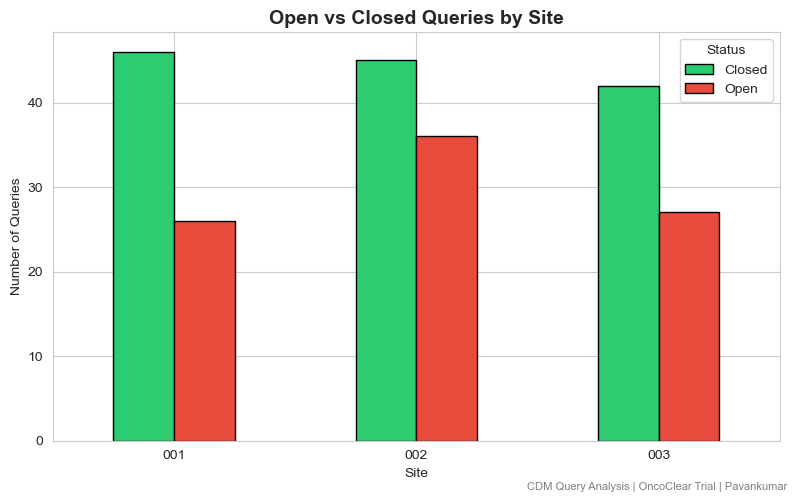

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

site_status = query_df.groupby(['site', 'status']).size().unstack(fill_value=0)

site_status.plot(kind='bar', figsize=(8, 5), color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Open vs Closed Queries by Site', fontsize=14, fontweight='bold')
plt.xlabel('Site')
plt.ylabel('Number of Queries')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.figtext(0.99, 0.01, 'CDM Query Analysis | OncoClear Trial | Pavankumar',
            ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('queries_by_site.png', dpi=300)
plt.show()

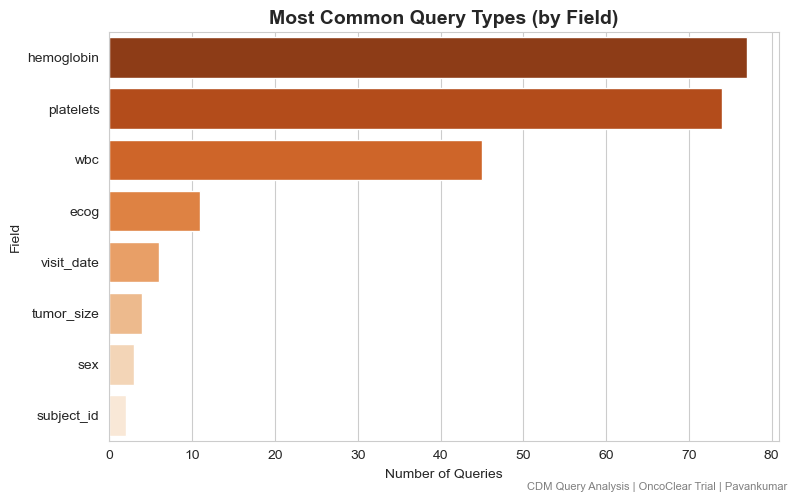

In [6]:
field_counts = query_df['field'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=field_counts.values, y=field_counts.index, 
            hue=field_counts.index, palette='Oranges_r', legend=False)
plt.title('Most Common Query Types (by Field)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Queries')
plt.ylabel('Field')
plt.figtext(0.99, 0.01, 'CDM Query Analysis | OncoClear Trial | Pavankumar',
            ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('query_types.png', dpi=300)
plt.show()

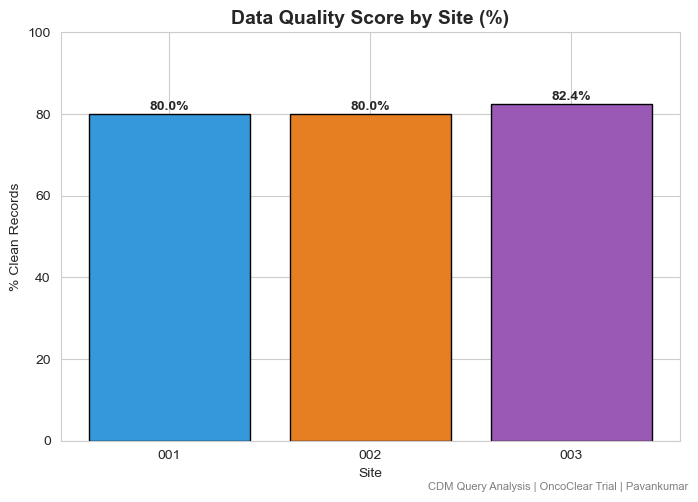

In [7]:
# Quality score = % of records with NO queries raised
total_records_per_site = df.groupby('site').size()
queried_records_per_site = query_df.groupby('site')['subject_id'].nunique()

quality_score = ((total_records_per_site - queried_records_per_site) / 
                  total_records_per_site * 100).round(1)

plt.figure(figsize=(7, 5))
bars = plt.bar(quality_score.index, quality_score.values, 
               color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='black')
plt.title('Data Quality Score by Site (%)', fontsize=14, fontweight='bold')
plt.xlabel('Site')
plt.ylabel('% Clean Records')
plt.ylim(0, 100)
for bar, val in zip(bars, quality_score.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', fontweight='bold')
plt.figtext(0.99, 0.01, 'CDM Query Analysis | OncoClear Trial | Pavankumar',
            ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('data_quality_score.png', dpi=300)
plt.show()

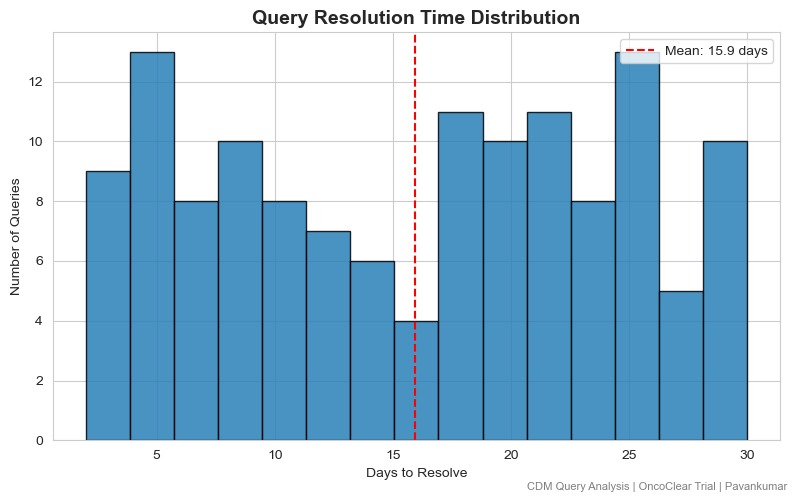

In [8]:
closed_queries = query_df[query_df['status'] == 'Closed']

plt.figure(figsize=(8, 5))
plt.hist(closed_queries['days_open'], bins=15, color='#2980b9', 
         edgecolor='black', alpha=0.85)
plt.title('Query Resolution Time Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Days to Resolve')
plt.ylabel('Number of Queries')
plt.axvline(closed_queries['days_open'].mean(), color='red', 
            linestyle='--', label=f"Mean: {closed_queries['days_open'].mean():.1f} days")
plt.legend()
plt.figtext(0.99, 0.01, 'CDM Query Analysis | OncoClear Trial | Pavankumar',
            ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('resolution_time.png', dpi=300)
plt.show()

In [9]:
df_clean.to_csv('oncoclear_clean_data.csv', index=False)
df.to_csv('oncoclear_messy_data.csv', index=False)
query_df.to_csv('oncoclear_query_report.csv', index=False)

print("All files exported successfully")
print(f"Clean data: {df_clean.shape}")
print(f"Messy data: {df.shape}")
print(f"Query report: {query_df.shape}")

All files exported successfully
Clean data: (250, 17)
Messy data: (260, 17)
Query report: (222, 10)


In [10]:
import os
print("Current folder:", os.getcwd())
print("\nFiles in this folder:")
for f in os.listdir():
    print(f)

Current folder: C:\Users\Pavankumar

Files in this folder:
.anaconda
.conda
.continuum
.ipynb_checkpoints
.ipython
.jupyter
.matplotlib
anaconda3
anaconda_projects
AppData
Application Data
conditional statements.ipynb
Contacts
Cookies
data_quality_score.png
DaVinci Resolve Media
day1 batch43.ipynb
Desktop
Documents
Downloads
Dropbox
Favorites
Links
Local Settings
loop statements.ipynb
Music
My Documents
NetHood
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{2623ad57-828a-11f0-b13a-50fe0c15ae45}.TM.blf
NTUSER.DAT{2623ad57-828a-11f0-b13a-50fe0c15ae45}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{2623ad57-828a-11f0-b13a-50fe0c15ae45}.TMContainer00000000000000000002.regtrans-ms
ntuser.ini
oncoclear_clean_data.csv
oncoclear_messy_data.csv
oncoclear_query_report.csv
OneDrive
pavan pdc pdf.pdf
Pictures
PrintHood
project 1
queries_by_site.png
query_types.png
Recent
resolution_time.png
Saved Games
Searches
SendTo
serious_breakdown.png
signal_type_breakdown.png
Start Menu
Templa